# Feature Engineering

In [12]:
%load_ext IPython.extensions.autoreload
%autoreload 2

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [45]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 8.9 MB/s eta 0:00:00


In [13]:
import sys,os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [14]:
import numpy as np
from src.data_reader import DataSource, read_vertices_VTK, num_vertices_VTK
from src.descriptors.dscs_driver import compute_descriptors

from src.utils import get_free_id, write_jsonl, clear_jsonl

!pip install numpy==1.23.0

In [15]:
from ripser import ripser
from persim import plot_diagrams

In [16]:
from gudhi import RipsComplex, AlphaComplex, plot_persistence_diagram
from gudhi.representations import ProminentPoints
from gudhi.representations import PersistenceImage

In [17]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report

import joblib

In [18]:
import csv

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary as torch_summary

from IPython.display import display, clear_output

from src.learning.nn import SimpleNN, train, predict

In [21]:
Model = 'Combined'

data_base = './data/data/'

save_descs_path = os.path.join(data_base,'saved_descriptors/')

data = np.load(os.path.join(save_descs_path,Model+'Data.npy'))
labels = np.load(os.path.join(save_descs_path,Model+'Labels.npy'))

print(data.shape, labels.shape)

(9244, 13) (9244,)


In [28]:
Model = 'AlphaProminent'

data_base = './data/small_data/'

save_descs_path = os.path.join(data_base,'saved_descriptors/')

data2 = np.load(os.path.join(save_descs_path,Model+'Data.npy'))
labels2 = np.load(os.path.join(save_descs_path,Model+'Labels.npy'))

print(data2.shape, labels2.shape)

(900, 75) (900,)


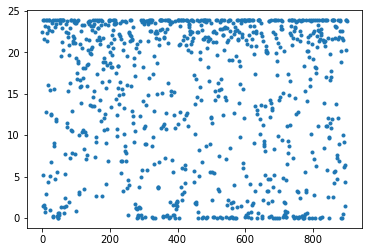

In [43]:
plt.plot(data2[:,5],'.')

array([23.73555695, 23.71019992, 23.55179606, 23.86607939, 23.86914419,
       23.2350343 , 23.73865752, 23.81071612, 23.54561055, 23.527994  ,
       23.27538915, 23.71059864, 23.86968134, 23.87024573, 23.64270817,
       23.7618489 , 23.58592541, 23.55060997, 23.79513515, 23.86949947,
       23.86887581, 23.78071004, 23.32646448, 23.25789882, 23.59213973,
       23.31691495, 23.4018376 , 23.60505211, 23.77208422, 23.85311446,
       23.83057885, 23.49211848, 23.86929078, 23.36519526, 23.5508849 ,
       23.62932385, 23.09428367, 23.39794311, 23.75982515, 23.86981452,
       23.55131623, 23.45628482, 23.8205702 , 23.8684337 , 23.66238473,
       23.51589861, 23.28434788, 23.71081012, 23.70977896, 23.70921285,
       23.70601284, 23.86942924, 23.86927578, 23.86942605, 23.8303666 ,
       23.71624311, 23.31115585, 23.86961846, 23.73266445, 23.79134193,
       23.86904043, 23.86890106, 23.72244537, 23.8692708 , 23.49515425,
       23.2033064 , 22.94552139, 23.7117186 , 23.71099022, 23.52

### Visualize correlations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


n, p = data2.shape[0], data2.shape[1]


# Initialize R^2 matrix
R2_matrix = np.zeros((p, p))

# Compute R^2 for each pair of features
for i in range(p):
    for j in range(p):
        if i == j:
            R2_matrix[i, j] = 1.0  # R^2 of a feature with itself is 1
        else:
            model = LinearRegression().fit(data2[:, i].reshape(-1, 1), data2[:, j])
            R2_matrix[i, j] = model.score(data2[:, i].reshape(-1, 1), data2[:, j])

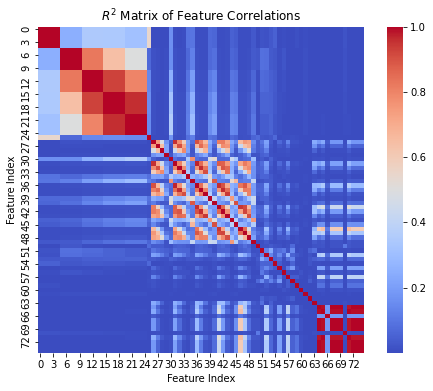

In [ ]:
# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(R2_matrix, annot=False, cmap="coolwarm", fmt=".2f", square=True)
plt.title("$R^2$ Matrix of Feature Correlations")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")
plt.show()

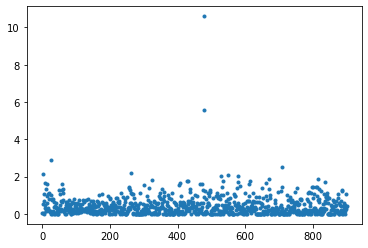

In [56]:
plt.plot(data2[:,], '.')

In [58]:
n, p = data.shape[0], data.shape[1]


# Initialize R^2 matrix
R2_matrix = np.zeros((p, p))

# Compute R^2 for each pair of features
for i in range(p):
    for j in range(p):
        if i == j:
            R2_matrix[i, j] = 1.0  # R^2 of a feature with itself is 1
        else:
            model = LinearRegression().fit(data[:, i].reshape(-1, 1), data[:, j])
            R2_matrix[i, j] = model.score(data[:, i].reshape(-1, 1), data[:, j])

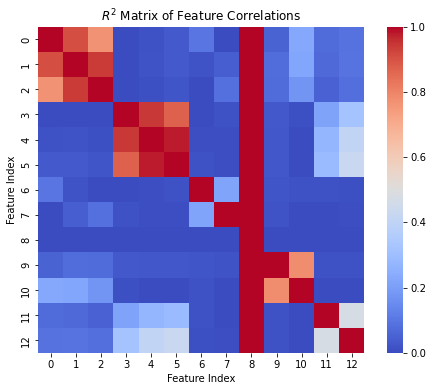

In [59]:
# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(R2_matrix, annot=False, cmap="coolwarm", fmt=".2f", square=True)
plt.title("$R^2$ Matrix of Feature Correlations")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")
plt.show()

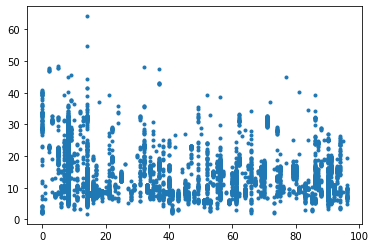

In [69]:
plt.plot( labels, data[:,9], '.')

In [102]:
StrShSp = StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=None)

# get indices of split
train_idx, val_idx = next(StrShSp.split(data2, labels2))

train_data = data2[train_idx,:]
train_labels = labels2[train_idx]

val_data = data2[val_idx]
val_labels = labels2[val_idx]

In [114]:
N_Estimators = 100
criterion = 'entropy'

columns = list(range(0,75,1))
#columns = [0,1,2,3,4,5]
#columns = [6,7,9,10,11,12]

forest = RandomForestClassifier(n_estimators=N_Estimators, criterion=criterion)
forest.fit(train_data[:,columns], train_labels)

pred_labels = forest.predict(val_data[:,columns])

In [115]:
acc = accuracy_score(val_labels, pred_labels)

print(acc)

0.6277777777777778


In [79]:
train_data[0,0:6]

array([ 1.84079116e+01,  2.43647396e+01,  3.05609505e+01, -3.20907436e+03,
       -1.58385770e+04, -2.87071984e+04])

## Notes
For the **sublevel set filtration**
- In sublevelset **there is no H_2**
- Using only `quantiles[0]` and `charge[0]` yelds 68%, but using all quantiles and all charges yields 84.5%.
So maybe use more steps! A finer subdivision of the steps
- Also, maybe move to the residuals wrt a linear regression
For the **Alpha filtration**
- With 5x5 persistent images, using all 75 columns yields 63%, using only every fifth column yields 57%